In [1]:
import h5py 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import scipy.interpolate as interpolate
import scipy.integrate as integrate
import scipy.stats
from scipy.linalg import toeplitz
from scipy.stats import uniform, loguniform
import os
import seaborn as sns

import sys
sys.path.append("/home/sunny.ng/nicer_eos_ext/semiparameos/")
import utils
from utils import clean_conditioning
import tqdm

### Nucleon mass in grams
mass_of_nucleon = 1/(6.02 * 10**23)
### Nucleon mass in MeV/c2
nucleon_mass_in_MeV = 939
### Conversion factors for Mev,fm to CGS units
gcm3_to_dynecm2=8.9875e20 
MeV_to_gcm3 = 1.7827e12 
dynecm2_to_MeVFermi = 1.6022e33
gcm3_to_fm4 = 3.5178e14

fm_in_cgs = 1e-13
rho_nuc_in_cgs = .16 * mass_of_nucleon / (fm_in_cgs)**3
rho_nuc_nicer_cgs = 267994004080000.03

default_hyperparameters = {"gamma_low":.1, "gamma_high":1.5,
                           "alpha_low":.1, "alpha_high":5.,
                           "corr_len_low":1e-3, "corr_len_high":1e1}

gp_hyp_gamma = .7
gp_hyp_alpha = 1.
gp_hyp_corr_len = 1e-2

/home/sunny.ng/semiparameos/executables/TOVSolver.py:17: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal
/cvmfs/software.igwn.org/conda/envs/igwn-py311/lib/python3.11/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/lat

In [2]:
plt.rcParams["font.family"] = "cmr10"      # Computer Modern Roman
plt.rcParams["mathtext.fontset"] = "cm"    # match math text to Computer Modern
plt.rcParams["axes.unicode_minus"] = False # optional, fixes minus sign rendering

In [3]:
def agn_collect_data(eos_dir, rho_vals_to_interp, tov_dir = ".", weights = False,
                     truncate_central = False, truncate_at_sat = False,
                     weight_columns = []):
    """
    Gather nuclear EoSs with equal weights for training the Gaussian Process.
    *Phase transitions may pose an issue.*
    """ 
    eos_path = f"{eos_dir}/eos_tables/" 
    eos_list = os.listdir(eos_path)
    data = np.zeros((len(eos_list), len(rho_vals_to_interp)))
    ### no need to sample according to weights --> use all
    if not weights:
        for i, eos in enumerate(eos_list):
            try:
                eos_data = pd.read_csv(f"{eos_path}/{eos}", header = 1, sep = r"\s+")
            except:
                raise KeyError(f"{eos} not found within directory. Available EoS's are: {eos_list}")
                
            if truncate_central:
                ### Truncate at central density corresponding to M_tov
                try:
                    macros_file = f"{os.path.splitext(eos)[0]}.tab"
                    eos_data = clean_conditioning.mtov_truncate(eos_dir,
                                                                macros_file,
                                                                eos_data) ### eos_data assumed to be a dataframe
                except:
                    print("No corresponding TOV file found. Pressing onward...")
                    continue
            if truncate_at_sat: 
                ### Truncate after nuclear saturation density to ignore crust inhomogeneities
                ### BREAKS CONDITIONING. DUE TO MISSING VALUES WHERE INTERPOLANT SEARCHES FOR SOUND SPEED
                
                eos_data = eos_data[eos_data["n(fm-3)"] > 0.16] 
            
            phi_data = np.log(np.gradient(eos_data["rho(MeVfm-3)"],eos_data["P(MeVfm-3)"]) - 1.0)
            data[i,:] = interpolate.griddata(eos_data["n(fm-3)"]*mass_of_nucleon/fm_in_cgs**3, phi_data, rho_vals_to_interp)
            
            ### "Extend" nuclear training data interpolants to higher densities
            if any(np.isnan(x) for x in data[i,:]):
                idxs = np.where(np.isnan(data[i,:]))[0]
                if any(np.diff(idxs)) > 1: # check if missing points are close together
                    raise ValueError("Inconsistent sound speed detected.")
                elif all(np.diff(idxs)) == 1: # confirm NaN's are only at points past original interpolation range
                    causal_val = data[i,:][(np.where(np.isnan(data[i,:]))[0][0] - 1)]
                    data[i,:] = np.where(np.isnan(data[i,:]), causal_val, data[i,:]) # replace NaN's with phi based on last causal sound speed value
            
        return data

def from_samples(samples, tabulation_points, weights=None, *args, **kwargs):
    """
    Create a gaussian process from samples from a distribution
    
    In effect, approximate a distribution by it's first two moments
    """
    mean = np.mean(samples, axis=0)
    covariance = np.cov(samples, rowvar=False)
    tabulation_points = tabulation_points

    return covariance

def rqf(gamma, alpha, corr_len, tabulation_points):
    """
    This function calculates the elements of a covariance matrix according to
    the rational quadratic covariance function. Using this kernel equates to using
    multiple squared exponential kernels, across multiple length scales. Much like
    the squared exponential kernel, the gamma parameter determines the overall strength
    of the correlation, and l corresponds to the characteristic length scale of these
    correlations. Lastly, alpha acts as a weight to each of the length scales. 
    
    Note: It is required for alpha and l > 0. 
    """
    logrho = np.log(tabulation_points)
    ratquad = lambda x, x_prime: (gamma**2)*((1. +  (((np.linalg.norm([x - x_prime], 2))**2)/(2*alpha*(corr_len**2))))**(-alpha))
    K = np.empty((len(tabulation_points), len(tabulation_points)))
    for i, dens in enumerate(logrho):
        for j, dens_prime in enumerate(logrho):
            K[i,j] = ratquad(dens, dens_prime)
    return K

In [4]:
rho_vals_to_interp = np.geomspace(rho_nuc_in_cgs, 10*rho_nuc_in_cgs, 100)

In [5]:
samples = agn_collect_data(eos_dir = "/home/sunny.ng/XGEOSRecovery/eos_table/nuclear_set_PRD109-103029",
                                rho_vals_to_interp = rho_vals_to_interp,
                                truncate_central = True,
                                truncate_at_sat = False)

/cvmfs/software.igwn.org/conda/envs/igwn-py311/lib/python3.11/site-packages/numpy/lib/function_base.py:1242: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
/cvmfs/software.igwn.org/conda/envs/igwn-py311/lib/python3.11/site-packages/numpy/lib/function_base.py:1243: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/cvmfs/software.igwn.org/conda/envs/igwn-py311/lib/python3.11/site-packages/numpy/lib/function_base.py:1244: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
/cvmfs/software.igwn.org/conda/envs/igwn-py311/lib/python3.11/site-packages/numpy/lib/function_base.py:1250: RuntimeWarning: invalid value encountered in add
  out[tuple(slice1)] = a * f[tuple(slice2)] + b * f[tuple(slice3)] + c * f[tuple(slice4)]
/cvmfs/software.igwn.org/conda/envs/igwn-py311/lib/python3.11/site-packages/numpy/lib/function_base.py:1242: RuntimeWarning: divide by zero encountered in divide
  a = -

In [6]:
covar = from_samples(samples, np.log(rho_vals_to_interp))

In [7]:
covar

array([[ 0.05490747,  0.05479982,  0.05460757, ..., -0.19475619,
        -0.19475619, -0.19475619],
       [ 0.05479982,  0.05495025,  0.05498392, ..., -0.20987051,
        -0.20987051, -0.20987051],
       [ 0.05460757,  0.05498392,  0.05521818, ..., -0.22254573,
        -0.22254573, -0.22254573],
       ...,
       [-0.19475619, -0.20987051, -0.22254573, ...,  2.86319344,
         2.86319344,  2.86319344],
       [-0.19475619, -0.20987051, -0.22254573, ...,  2.86319344,
         2.86319344,  2.86319344],
       [-0.19475619, -0.20987051, -0.22254573, ...,  2.86319344,
         2.86319344,  2.86319344]])

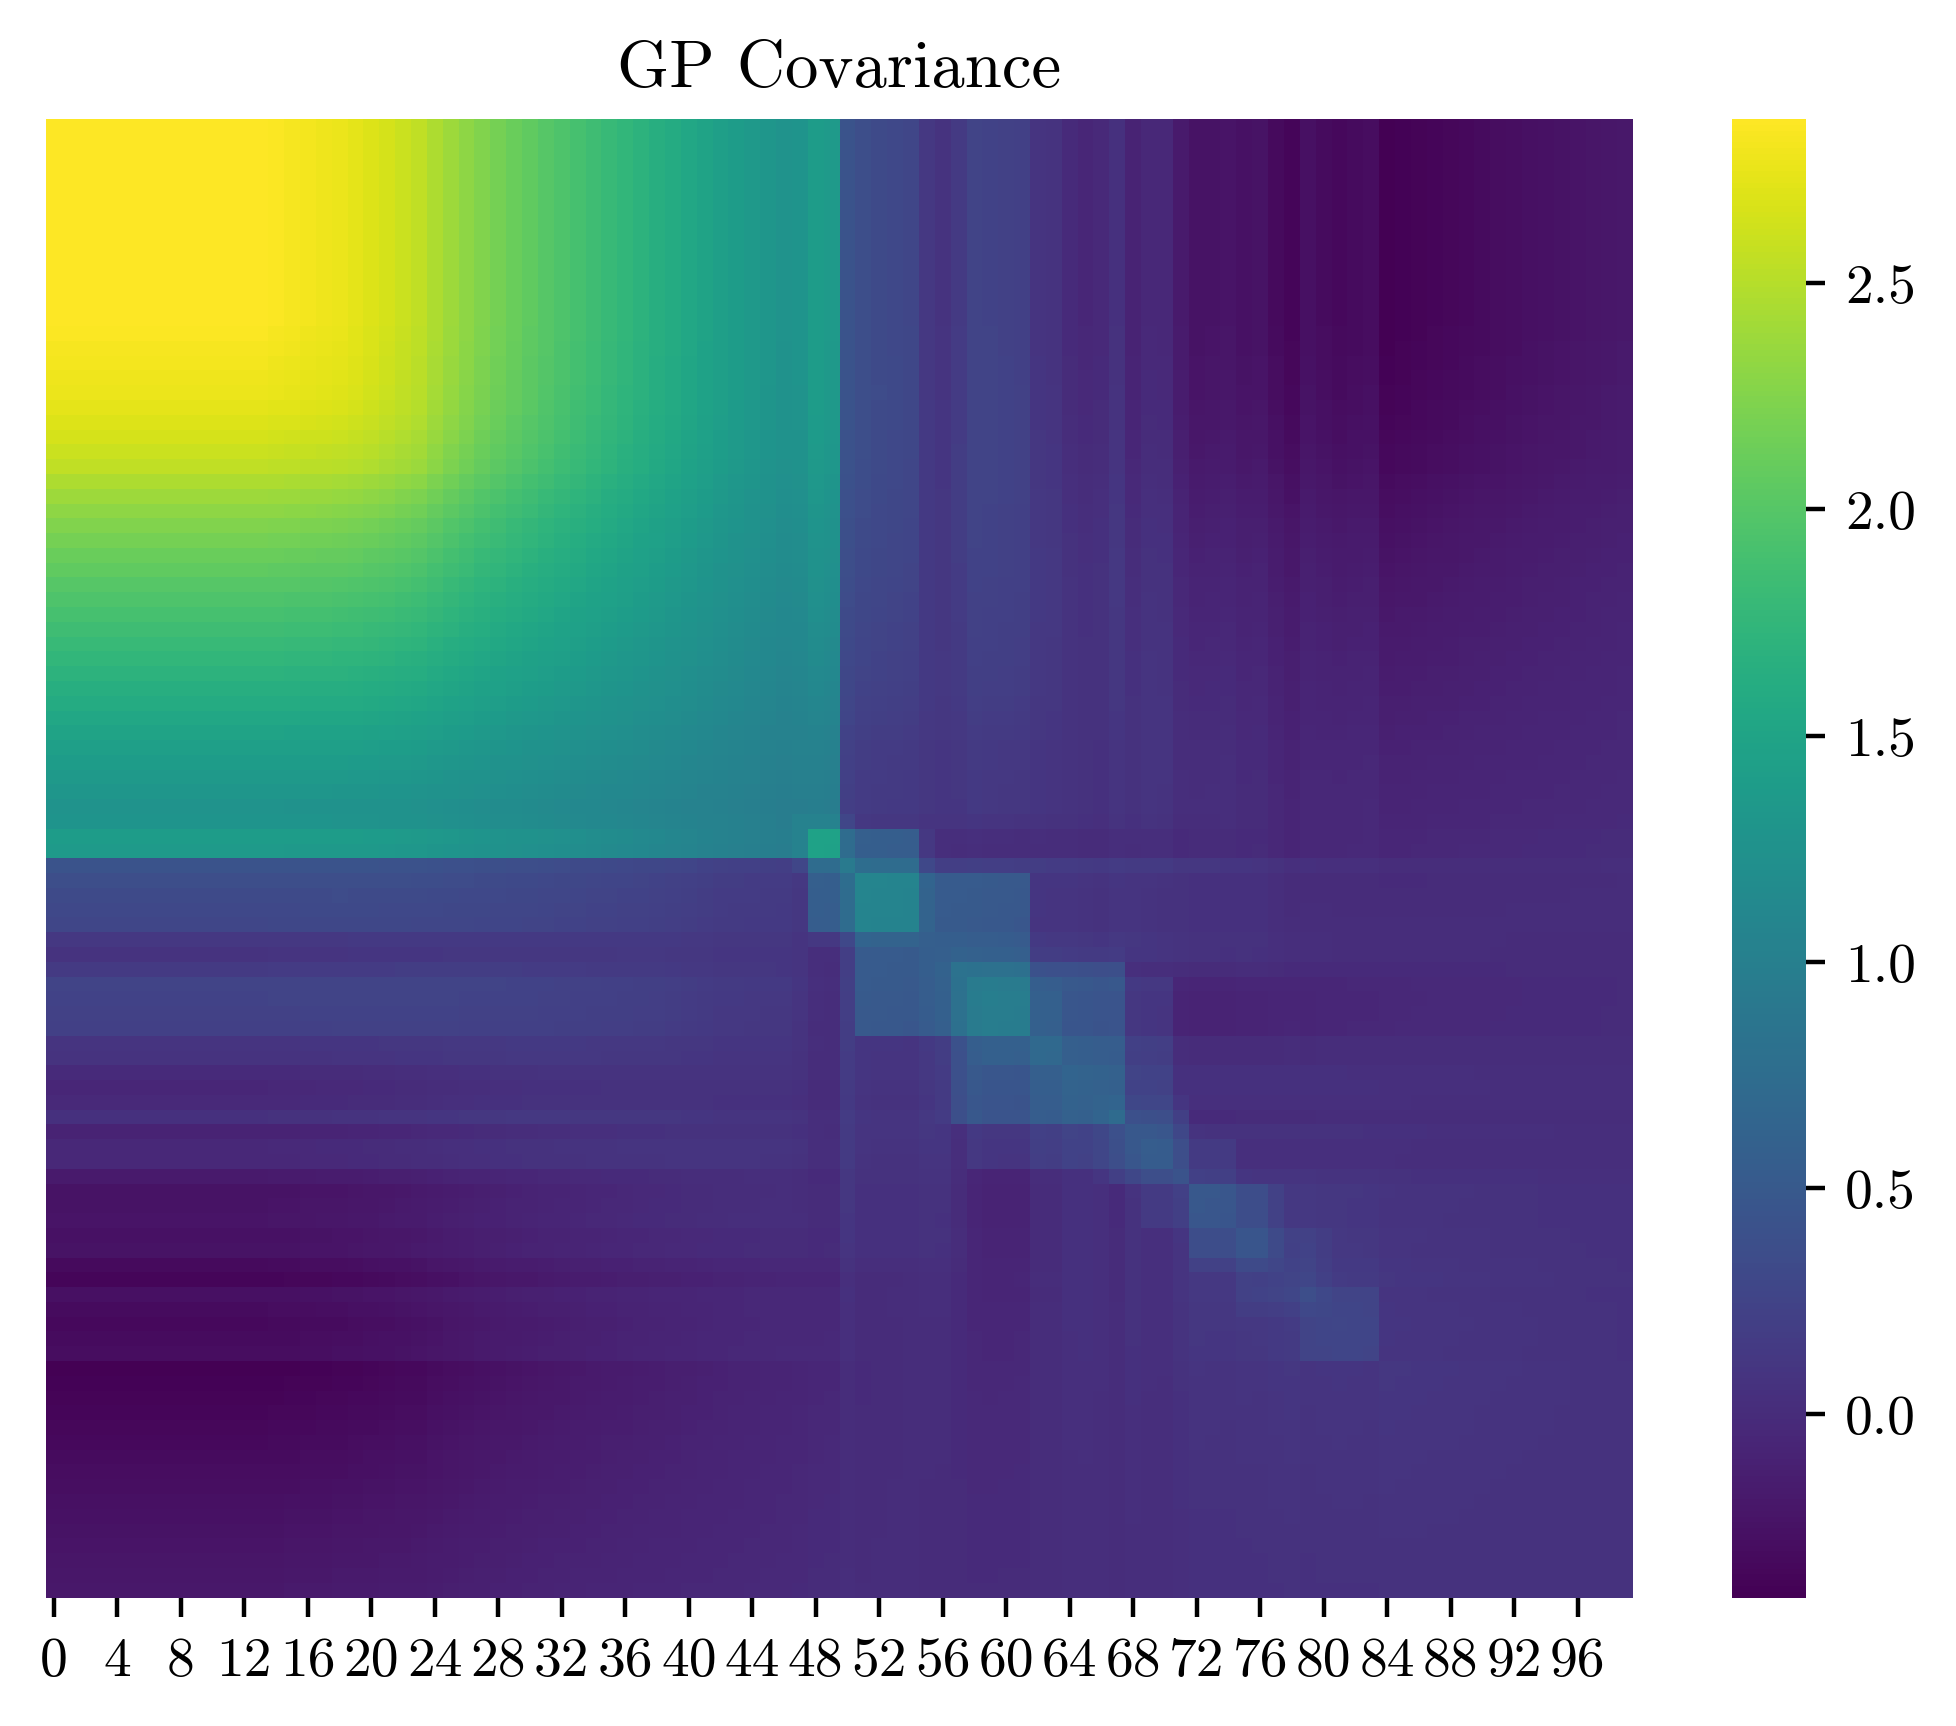

In [8]:
sns.heatmap(covar[::-1, ::-1], cmap="viridis", yticklabels=False)
plt.title("GP Covariance")
plt.gcf().set_dpi(400)
plt.show()

In [9]:
rqf_ker = rqf(gp_hyp_gamma, gp_hyp_alpha, gp_hyp_corr_len, np.log(rho_vals_to_interp))

In [10]:
act_covar = covar + rqf_ker

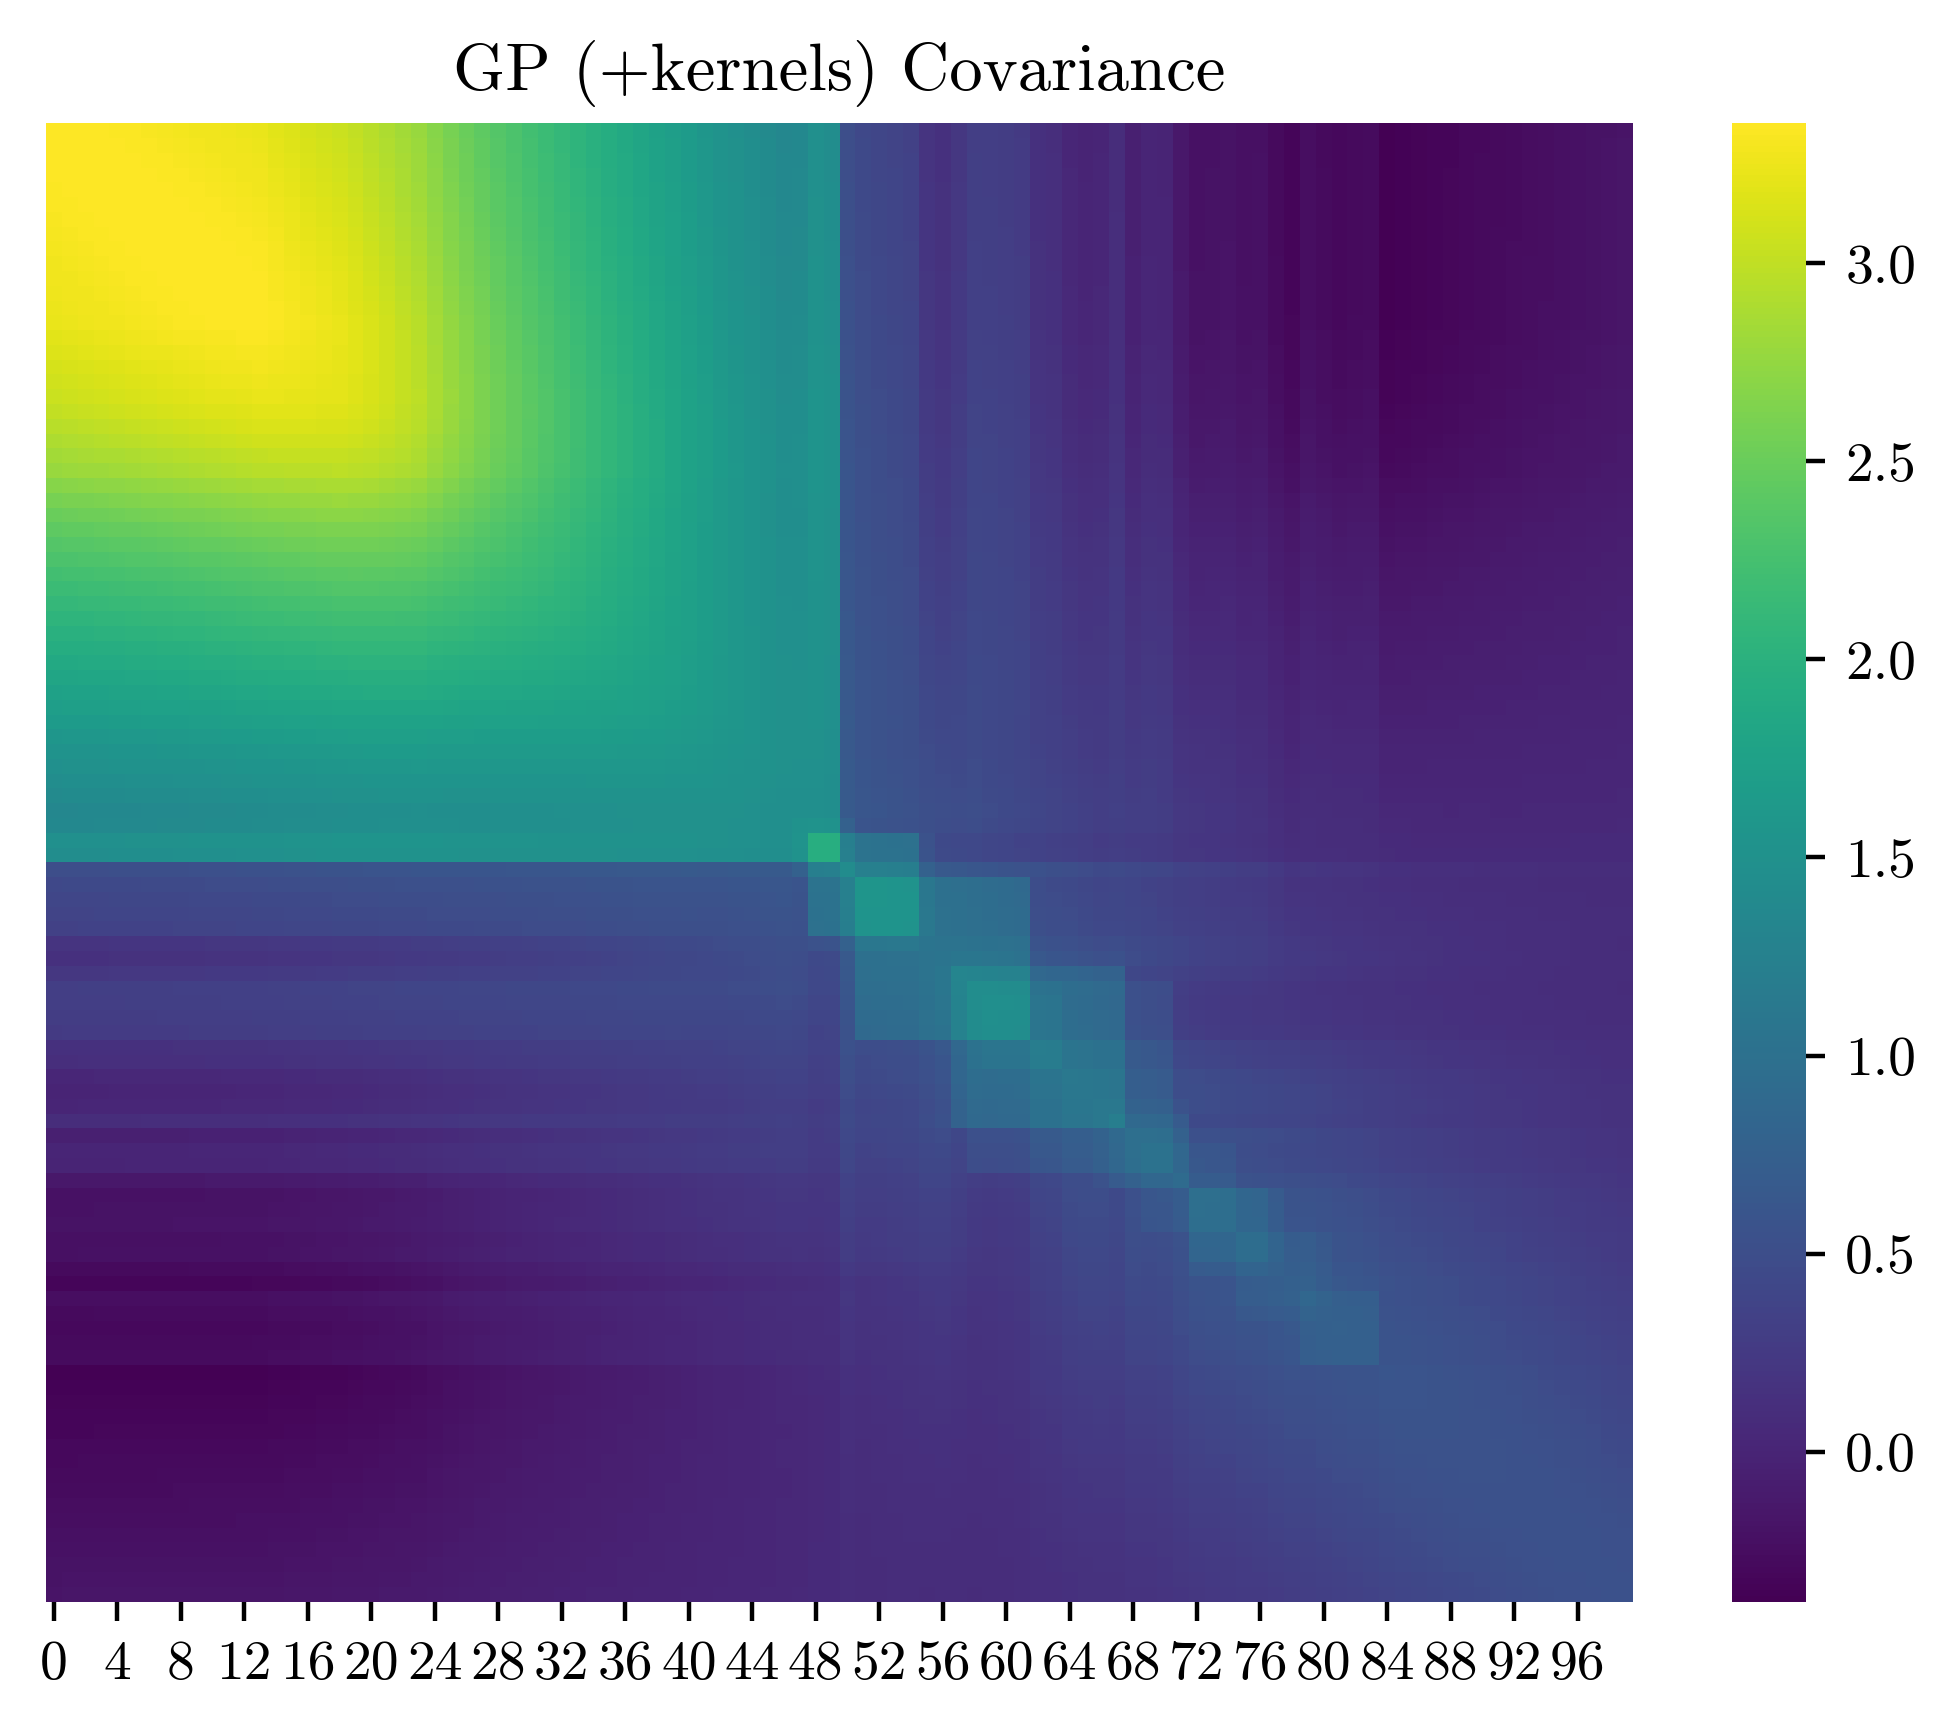

In [11]:
sns.heatmap(act_covar[::-1, ::-1], cmap="viridis", yticklabels=False)
plt.title("GP (+kernels) Covariance")
plt.gcf().set_dpi(400)
plt.show()

***
## Inspecting covariance matrices from three seperate matter groups
***

In [12]:
eos_directory = "/home/sunny.ng/pt_detection/nuclear_training_eos/matter_groups"
nucleon_eos_dir = f"{eos_directory}/nucleon"
hyperon_eos_dir = f"{eos_directory}/hyperon"
quark_eos_dir = f"{eos_directory}/quark"

In [13]:
nucleon_samples = agn_collect_data(eos_dir = nucleon_eos_dir,
                                rho_vals_to_interp = rho_vals_to_interp,
                                truncate_central = True,
                                truncate_at_sat = False)
hyperon_samples = agn_collect_data(eos_dir = hyperon_eos_dir,
                                rho_vals_to_interp = rho_vals_to_interp,
                                truncate_central = True,
                                truncate_at_sat = False)
quark_samples = agn_collect_data(eos_dir = quark_eos_dir,
                                rho_vals_to_interp = rho_vals_to_interp,
                                truncate_central = True,
                                truncate_at_sat = False)

/tmp/ipykernel_174/653438650.py:35: RuntimeWarning: invalid value encountered in log
  phi_data = np.log(np.gradient(eos_data["rho(MeVfm-3)"],eos_data["P(MeVfm-3)"]) - 1.0)
/cvmfs/software.igwn.org/conda/envs/igwn-py311/lib/python3.11/site-packages/numpy/lib/function_base.py:1242: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
/cvmfs/software.igwn.org/conda/envs/igwn-py311/lib/python3.11/site-packages/numpy/lib/function_base.py:1243: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/cvmfs/software.igwn.org/conda/envs/igwn-py311/lib/python3.11/site-packages/numpy/lib/function_base.py:1244: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
/cvmfs/software.igwn.org/conda/envs/igwn-py311/lib/python3.11/site-packages/numpy/lib/function_base.py:1250: RuntimeWarning: invalid value encountered in add
  out[tuple(slice1)] = a * f[tuple(slice2)] + b * f[tuple(slice3)] + c * f[tuple(slice

No corresponding TOV file found. Pressing onward...
No corresponding TOV file found. Pressing onward...
No corresponding TOV file found. Pressing onward...
No corresponding TOV file found. Pressing onward...
No corresponding TOV file found. Pressing onward...
No corresponding TOV file found. Pressing onward...
No corresponding TOV file found. Pressing onward...
No corresponding TOV file found. Pressing onward...
No corresponding TOV file found. Pressing onward...
No corresponding TOV file found. Pressing onward...
No corresponding TOV file found. Pressing onward...
No corresponding TOV file found. Pressing onward...
No corresponding TOV file found. Pressing onward...
No corresponding TOV file found. Pressing onward...
No corresponding TOV file found. Pressing onward...


***
## Get covariances for each set of composition

In [14]:
nuc_covar = from_samples(nucleon_samples, np.log(rho_vals_to_interp))
hyp_covar = from_samples(hyperon_samples, np.log(rho_vals_to_interp))
quark_covar = from_samples(quark_samples, np.log(rho_vals_to_interp))

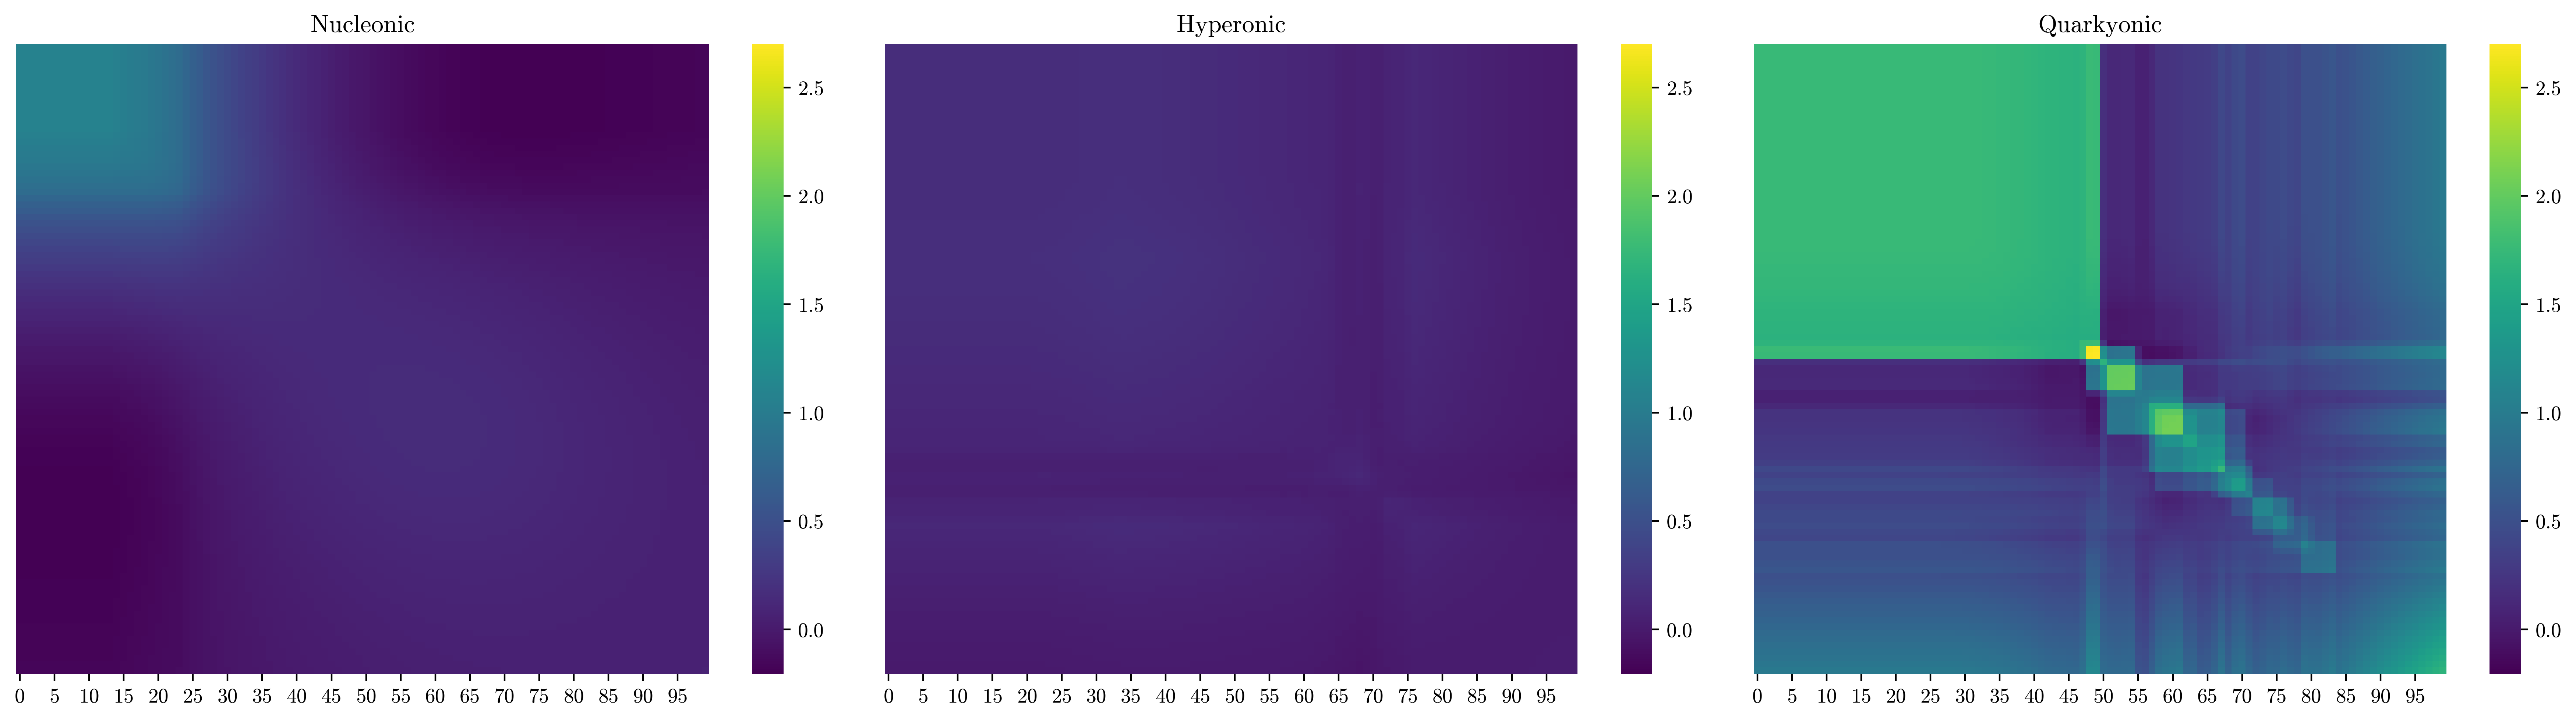

In [15]:
from matplotlib.colors import Normalize
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

vmin = min(nuc_covar.min(),hyp_covar.min(),quark_covar.min())
vmax = max(nuc_covar.max(),hyp_covar.max(),quark_covar.max())
norm = Normalize(vmin=vmin, vmax=vmax)

# Nucleon heatmap
sns.heatmap(nuc_covar[::-1, ::-1], yticklabels=False, ax=axes[0], cmap="viridis", norm = norm)
axes[0].set_title("Nucleonic")

# Hyperon heatmap
sns.heatmap(hyp_covar[::-1, ::-1], yticklabels=False, ax=axes[1], cmap="viridis", norm = norm)
axes[1].set_title("Hyperonic")

# Quark heatmap
sns.heatmap(quark_covar[::-1, ::-1], yticklabels=False, ax=axes[2], cmap="viridis", norm = norm)
axes[2].set_title("Quarkyonic")


plt.tight_layout()
plt.gcf().set_dpi(400)
plt.show()

***
### Let's perform PCA on these different covariance matrices

In [16]:
### Clean data --> whiten first
sigma = np.array([quark_covar[i,i]**.5 for i in range(quark_covar.shape[0])])
    
# this is the normalized covariance
covar_whitened = np.diag(1/sigma) @ quark_covar @ np.diag(1/sigma)

In [17]:
quark_eig_vals, quark_eig_vec = np.linalg.eig(quark_covar)
print(abs(quark_eig_vals))
# len(abs(quark_eig_vals))

[9.55264707e+001 2.54145202e+001 9.57915540e+000 7.82339864e+000
 3.68733290e+000 2.92377776e+000 2.49095223e+000 1.66173208e+000
 8.30172317e-001 6.16466796e-001 4.17346206e-001 3.29284551e-001
 2.30236688e-001 5.56643607e-002 9.33751459e-015 7.91802776e-015
 3.68709139e-015 3.68709139e-015 3.62126017e-015 3.62126017e-015
 3.18833024e-015 3.18833024e-015 3.13869688e-015 3.13869688e-015
 2.58417860e-015 2.58417860e-015 2.68340313e-015 2.52404781e-015
 2.10014526e-015 2.10014526e-015 2.16536353e-015 1.77300155e-015
 1.77300155e-015 2.37832927e-015 2.15407923e-015 2.15407923e-015
 1.98640721e-015 2.01983837e-015 1.96872498e-015 1.83896934e-015
 1.67581135e-015 1.67581135e-015 1.69353024e-015 1.53903475e-015
 1.24210596e-015 1.24210596e-015 1.56248119e-015 1.32424656e-015
 1.32424656e-015 1.33832899e-015 1.03827754e-015 1.03827754e-015
 1.05251220e-015 1.21018560e-015 9.30558602e-016 1.00907848e-015
 1.00907848e-015 7.81358900e-016 7.81358900e-016 7.34318219e-016
 5.37802342e-016 5.378023

In [19]:
def project_psd(M, eps=0.0):
    M = 0.5 * (M + M.T)
    w, V = np.linalg.eigh(M)
    w = np.maximum(w, eps)
    return (V * w) @ V.T

In [20]:
K_new = transplant_block(quark_covar, src=slice(15, 50), dest=slice(50, 100))
K_new = project_psd(K_new, eps=1e-10)

### Adapt to tabulation grid of N points

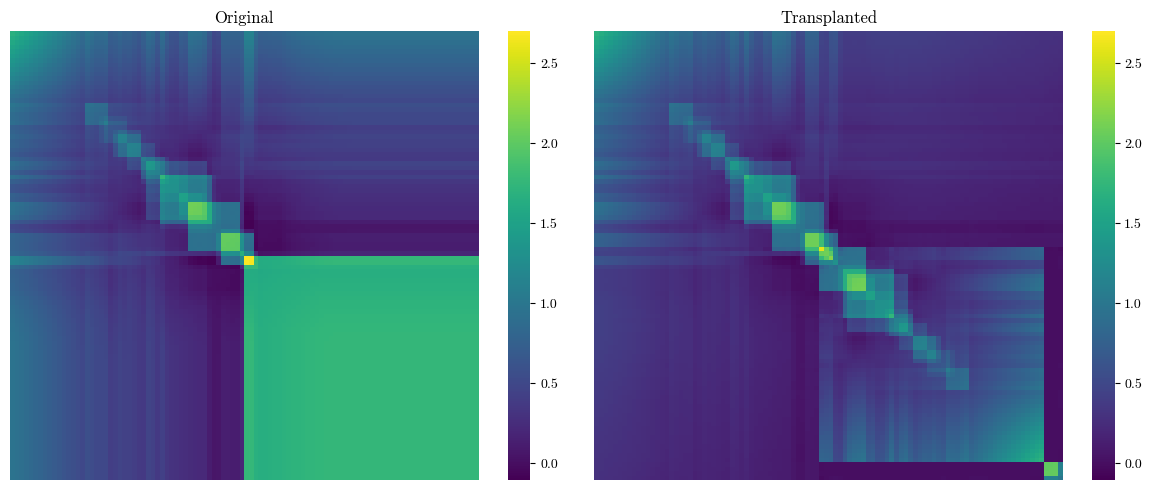

In [30]:
def transplant_block(K, tabulation_points, src_range, dest_range, corner_floor=0.5):
    K = K.copy()
    src  = slice(np.searchsorted(tabulation_points, src_range[0]),
                 np.searchsorted(tabulation_points, src_range[1], side='right'))
    dest = slice(np.searchsorted(tabulation_points, dest_range[0]),
                 np.searchsorted(tabulation_points, dest_range[1], side='right'))

    B = K[src, src][::-1, ::-1]                          # <-- reflect
    s, n = B.shape[0], dest.stop - dest.start

    K[dest, dest] = 0
    for off in range(0, n, s):
        end = min(off + s, n)
        K[dest.start+off:dest.start+end, dest.start+off:dest.start+end] = B[:end-off, :end-off]

    mask = np.zeros(K.shape[0], bool); mask[dest] = True
    i, j = np.where(~mask)[0], np.where(mask)[0]
    d = np.abs(i[:, None] - j[None, :]).astype(float)
    taper = corner_floor ** (d / d.max())
    K[np.ix_(i, j)] *= taper
    K[np.ix_(j, i)] = K[np.ix_(i, j)].T

    w, V = np.linalg.eigh(0.5 * (K + K.T))
    return (V * np.maximum(w, 1e-10)) @ V.T

K_new = transplant_block(
    quark_covar,
    rho_vals_to_interp,
    src_range=(2e14, 8e14),
    dest_range=(8e14, 1e16),
    corner_floor=0.3,
)

vmax = max(quark_covar.max(), K_new.max())
vmin = min(quark_covar.min(), K_new.min())
norm = Normalize(vmin=vmin, vmax=vmax)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(quark_covar, ax=ax[0], cmap="viridis", norm=norm,
            yticklabels=False, xticklabels=False)
ax[0].set_title("Original")
sns.heatmap(K_new, ax=ax[1], cmap="viridis", norm=norm,
            yticklabels=False, xticklabels=False)
ax[1].set_title("Transplanted")
plt.tight_layout()
plt.show()